In [72]:
from google.colab import drive
drive.mount("/content/mount")

Mounted at /content/mount


In [0]:
import pandas as pd
import cv2
import numpy as np
from glob import glob
import seaborn as sns
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import os


In [3]:
train_folder = "/content/mount/My Drive/CNN/train"
images_per_class = {}
print(glob(train_folder))


['/content/mount/My Drive/CNN/train']


In [0]:
for class_folder_name in os.listdir(train_folder):
    class_folder_path = os.path.join(train_folder, class_folder_name)
    class_label = class_folder_name
    images_per_class[class_label] = []
    for image_path in glob(os.path.join(class_folder_path, "*.png")):
        image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
        images_per_class[class_label].append(image_bgr)

In [10]:
path_to_images = '/content/mount/My Drive/CNN/train/*/*.png'
images = glob(path_to_images)
trainingset = []
traininglabels = []
num = len(images)
count = 1
#READING IMAGES AND RESIZING THEM
for i in images:
    print(str(count)+'/'+str(num),end='\r')
    trainingset.append(cv2.resize(cv2.imread(i),(70,70)))
    traininglabels.append(i.split('/')[-2])
    count=count+1
trainingset = np.asarray(trainingset)
traininglabels = pd.DataFrame(traininglabels)

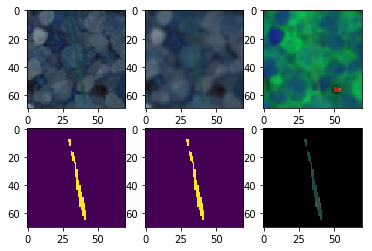

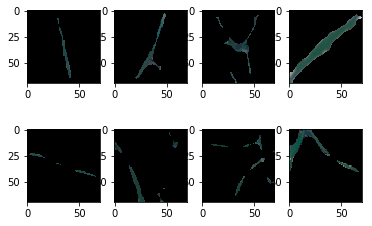

In [40]:
new_train = []
sets = []; getEx = True
for i in trainingset:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    #GREEN PARAMETERS
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    new = np.zeros_like(i,np.uint8)
    new[boolean] = i[boolean]
    new_train.append(new)
    
    if getEx:
        plt.subplot(2,3,1);plt.imshow(i) # ORIGINAL
        plt.subplot(2,3,2);plt.imshow(blurr) # BLURRED
        plt.subplot(2,3,3);plt.imshow(hsv) # HSV CONVERTED
        plt.subplot(2,3,4);plt.imshow(mask) # MASKED
        plt.subplot(2,3,5);plt.imshow(boolean) # BOOLEAN MASKED
        plt.subplot(2,3,6);plt.imshow(new) # NEW PROCESSED IMAGE
        plt.show()
        getEx = False
new_train = np.asarray(new_train)

# CLEANED IMAGES
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(new_train[i])

In [41]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.utils import np_utils

labels = preprocessing.LabelEncoder()
labels.fit(traininglabels[0])
print('Classes'+str(labels.classes_))
encodedlabels = labels.transform(traininglabels[0])
clearalllabels = np_utils.to_categorical(encodedlabels)
classes = clearalllabels.shape[1]
print(str(classes))


Classes['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']
12


In [0]:
new_train = new_train/255
x_train, x_test, y_train, y_test = train_test_split(new_train,clearalllabels,test_size=0.2,random_state=51,stratify=clearalllabels)

In [0]:
from keras.preprocessing.image import ImageDataGenerator
generator = ImageDataGenerator(rotation_range = 180,zoom_range = 0.1,width_shift_range = 0.1,height_shift_range = 0.1,horizontal_flip = True,vertical_flip = True)
generator.fit(x_train)

In [44]:
#3. Initialize & build the model (20 points)
#4. Optimize the model (16 points)
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Convolution2D, MaxPooling2D,Conv2D
from keras import regularizers

weight_decay = 1e-4
# create  model
model = Sequential()
model.add(Convolution2D(128,5,5,activation='relu', input_shape = (70,70,3)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(32, (5,5), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
 
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
 
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))
 
model.add(Flatten())
model.add(Dense(12, activation='softmax'))
 

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='sgd')
model.summary()
model.fit(x_train, y_train,
              batch_size=128, nb_epoch=40,
              verbose=1,
              validation_data=(x_test, y_test))


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:9: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (5, 5), activation="relu", input_shape=(70, 70, 3...)`
  if __name__ == '__main__':


Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_31 (Conv2D)           (None, 66, 66, 128)       9728      
_________________________________________________________________
activation_31 (Activation)   (None, 66, 66, 128)       0         
_________________________________________________________________
batch_normalization_31 (Batc (None, 66, 66, 128)       512       
_________________________________________________________________
conv2d_32 (Conv2D)           (None, 66, 66, 32)        102432    
_________________________________________________________________
activation_32 (Activation)   (None, 66, 66, 32)        0         
_________________________________________________________________
batch_normalization_32 (Batc (None, 66, 66, 32)        128       
_________________________________________________________________
max_pooling2d_16 (MaxPooling (None, 33, 33, 32)       

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:45: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 6181 samples, validate on 1546 samples
Epoch 1/40
6181/6181 [==============================] - 18s 3ms/step - loss: 6.1073 - acc: 0.3043 - val_loss: 5.6771 - val_acc: 0.1992
Epoch 2/40
6181/6181 [==============================] - 16s 3ms/step - loss: 3.4953 - acc: 0.5164 - val_loss: 4.8030 - val_acc: 0.3583
Epoch 3/40
6181/6181 [==============================] - 16s 3ms/step - loss: 3.1741 - acc: 0.5921 - val_loss: 4.0759 - val_acc: 0.3739
Epoch 4/40
6181/6181 [==============================] - 16s 3ms/step - loss: 3.0023 - acc: 0.6260 - val_loss: 5.0744 - val_acc: 0.3480
Epoch 5/40
6181/6181 [==============================] - 16s 3ms/step - loss: 2.8877 - acc: 0.6552 - val_loss: 5.6239 - val_acc: 0.3545
Epoch 6/40
6181/6181 [==============================] - 16s 3ms/step - loss: 2.8412 - acc: 0.6717 - val_loss: 2.9488 - val_acc: 0.6488
Epoch 7/40
6181/6181 [==============================] - 16s 3ms/step - loss: 2.7601 - acc: 0.6941 - val_loss: 2.9603 - val_acc: 0.6585
Epoch 8

In [45]:
#5. Predict the accuracy for both train and test data
print(model.evaluate(x_train, y_train)) 

6181/6181 [==============================] - 7s 1ms/step
[0.1658317709052048, 0.9545381006309659]


In [47]:
print(model.evaluate(x_test, y_test))

1546/1546 [==============================] - 2s 1ms/step
[0.4350881595815138, 0.8952134541521406]


In [48]:
y_pred = model.predict(x_train)
y_class = np.argmax(y_pred, axis = 1) 
y_check = np.argmax(y_train, axis = 1) 
print(confusion_matrix(y_check,y_class))

[[ 109    0    0    0    2    1  138    0    0    0    0    0]
 [   0  306    5    0    1    0    0    0    0    0    0    0]
 [   0    0  446    4    6    0    0    0    1    0    0    0]
 [   0    0    0  973    2    0    2    0    0    0    0    0]
 [   4    0    0    0  174    0   17    0    0    0    0    0]
 [   0    0    0    0    1  577   25    0    0    0    0    0]
 [   0    0    0    0    0    1 1044    0    0    0    0    0]
 [   0    0    1    0    0    0    1  182    0    0    1    0]
 [   0    0    6    3   10    0   10    8  785    2    2    3]
 [   0    0    0    1    1    2    0    0    4  359    1    2]
 [   0    0    0    0    1    1    1    0    0    0  394    0]
 [   1    0    0    0    0    0    8    0    0    0    1  551]]


In [49]:
y_pred = model.predict(x_test)
y_class = np.argmax(y_pred, axis = 1) 
y_check = np.argmax(y_test, axis = 1) 
print(confusion_matrix(y_check,y_class))

[[ 14   0   0   0   2   0  46   0   0   0   0   0]
 [  0  62   6   0   0   3   0   0   1   2   3   1]
 [  0   0 111   0   2   0   0   0   0   0   2   0]
 [  0   0   0 243   0   0   2   0   0   0   0   0]
 [  5   0   0   0  30   0  12   0   2   0   0   0]
 [  0   0   0   0   0 145   6   0   0   0   0   0]
 [  4   0   0   0   4   1 251   0   2   0   0   0]
 [  0   1   0   3   0   2   0  33   0   1   4   2]
 [  0   0   2   1   0   0  12   2 187   0   0   3]
 [  0   0   2   1   1   2   0   0   2  83   1   0]
 [  0   0   0   0   0   1   2   0   0   1  95   0]
 [  1   0   1   0   0   0   2   0   5   0   1 130]]


In [74]:
# read test data
path_to_images = '/content/mount/My Drive/CNN/test/*.png'
images = glob(path_to_images)
testingset = []
testinglabels = []
num = len(images)
count = 1
#READING IMAGES AND RESIZING THEM
for i in images:
    print(str(count)+'/'+str(num),end='\r')
    testingset.append(cv2.resize(cv2.imread(i),(70,70)))
    testinglabels.append(i.split('/')[-1])
    count=count+1
testingset = np.asarray(testingset)


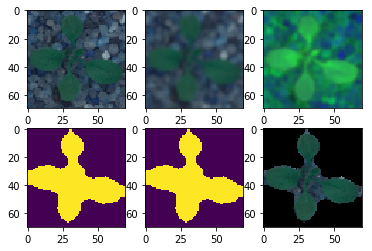

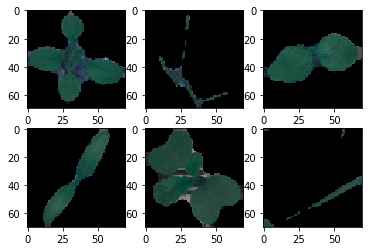

In [79]:
newtestimages = []
sets = []
getEx = True
for i in testingset:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    masking = np.zeros_like(i,np.uint8)
    masking[boolean] = i[boolean]
    newtestimages.append(masking)
    
    if getEx:
        plt.subplot(2,3,1);plt.imshow(i)
        plt.subplot(2,3,2);plt.imshow(blurr)
        plt.subplot(2,3,3);plt.imshow(hsv)
        plt.subplot(2,3,4);plt.imshow(mask)
        plt.subplot(2,3,5);plt.imshow(boolean)
        plt.subplot(2,3,6);plt.imshow(masking)
        plt.show()
        getEx=False

newtestimages = np.asarray(newtestimages)
# OTHER MASKED IMAGES
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(newtestimages[i])


In [80]:
newtestimages = newtestimages/255
y_pred = model.predict(newtestimages)
y_class = np.argmax(y_pred, axis = 1) 
predStr = labels.classes_[y_class]
result = {'file':testinglabels,'species':predStr}
result = pd.DataFrame(result)
#result.to_csv("Prediction.csv",index=False)
print(result)

              file                    species
0    1b490196c.png            Shepherds Purse
1    85431c075.png           Loose Silky-bent
2    506347cfe.png            Shepherds Purse
3    7f46a71db.png                 Sugar beet
4    668c1007c.png                   Charlock
5    71f5323c5.png           Loose Silky-bent
6    1f3f44563.png  Small-flowered Cranesbill
7    df521c0c0.png           Loose Silky-bent
8    780defa2e.png           Common Chickweed
9    beebe5f4e.png          Scentless Mayweed
10   466bb6d3b.png                      Maize
11   a9d2eab61.png           Loose Silky-bent
12   223e4af09.png                   Cleavers
13   98d819587.png            Shepherds Purse
14   abc331628.png               Common wheat
15   bffc08672.png          Scentless Mayweed
16   eef131644.png           Loose Silky-bent
17   1926e82fd.png           Loose Silky-bent
18   7d3045fc3.png                 Sugar beet
19   b7a7f6390.png                    Fat Hen
20   6dd095129.png           Commo